This code plots the following using the trajectories obtained from idtrackerai:
- Trajectories (over time)
- Inter-animal distance
- Speeds, acceleration
- Heading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

Data filtering

In [3]:
# Arena parameters from idtracker.ai ROI
cx, cy = 303, 1096
major_axis, minor_axis = 225, 230
angle_deg = 140
angle_rad = np.deg2rad(angle_deg)

a = major_axis / 2
b = minor_axis / 2

# Load trajectory data
csv_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_pattern_vs_nopattern/session_trimmed_output/trajectories/trajectories_csv/trajectories.csv" 
data = pd.read_csv(csv_path)

# Extract fish coordinates
traj_x1, traj_y1 = data.iloc[:, 1].values, data.iloc[:, 2].values
traj_x2, traj_y2 = data.iloc[:, 3].values, data.iloc[:, 4].values

# # Filter points inside ellipse
# def filter_inside_ellipse(x, y, cx, cy, a, b, theta):
#     x_shift = x - cx
#     y_shift = y - cy
#     cos_t = np.cos(theta)
#     sin_t = np.sin(theta)
#     term1 = ((x_shift * cos_t + y_shift * sin_t) ** 2) / (a ** 2)
#     term2 = ((x_shift * sin_t - y_shift * cos_t) ** 2) / (b ** 2)
#     return (term1 + term2) <= 1

# mask1 = filter_inside_ellipse(traj_x1, traj_y1, cx, cy, a, b, angle_rad)
# mask2 = filter_inside_ellipse(traj_x2, traj_y2, cx, cy, a, b, angle_rad)

# traj_x1, traj_y1 = traj_x1[mask1], traj_y1[mask1]
# traj_x2, traj_y2 = traj_x2[mask2], traj_y2[mask2]

# Downsample trajectories: every 1 second (at 60 fps)
step = 60 
traj_x1_ds = traj_x1[::step]
traj_y1_ds = traj_y1[::step]
traj_x2_ds = traj_x2[::step]
traj_y2_ds = traj_y2[::step]


Found 4 fish in the CSV


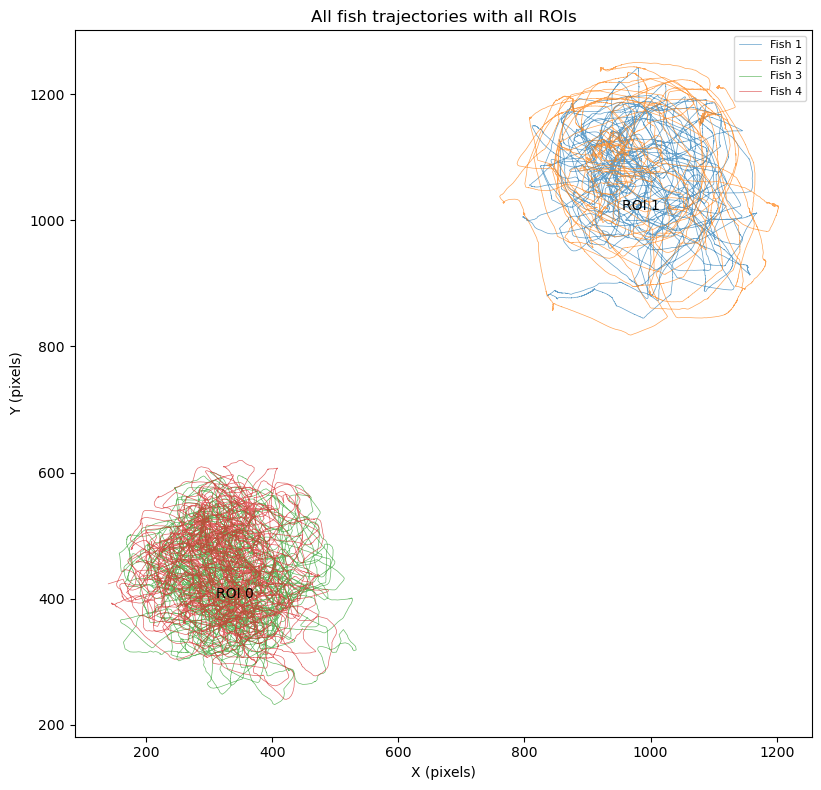

Fish 1 is in ROI 1
Fish 2 is in ROI 1
Fish 3 is in ROI 0
Fish 4 is in ROI 0


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# load trajectories
csv_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_pattern_vs_nopattern/session_trimmed_output/trajectories/trajectories_csv/trajectories.csv" 
data = pd.read_csv(csv_path)

# get total number of fish
n_fish = (data.shape[1] - 1) // 2  # subtract frame column
print(f"Found {n_fish} fish in the CSV")

# define ROIs
roi_list = [
    {'center': [341, 408], 'axes': [273, 278], 'angle': 85},
    {'center': [985, 1023], 'axes': [227, 283], 'angle': 36}
    # {'center': [1703, 440], 'axes': [261, 263], 'angle': 90},
    # {'center': [1047, 1037], 'axes': [292, 305], 'angle': 53},
    # {'center': [353, 442], 'axes': [291, 301], 'angle': 100},
]

# prepare plot
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.tab10.colors  # get 10 distinct colors

# plot all fish
for fish_id in range(1, n_fish+1):
    x_col = fish_id * 2 - 1
    y_col = fish_id * 2
    traj_x = data.iloc[:, x_col].values
    traj_y = data.iloc[:, y_col].values
    
    ax.plot(traj_x, traj_y, lw=0.5, alpha=0.7, color=colors[(fish_id-1)%10], label=f'Fish {fish_id}')

# draw ellipses for all ROIs
for idx, roi in enumerate(roi_list):
    cx, cy = roi['center']
    major_axis, minor_axis = roi['axes']
    angle = roi['angle']
    ellipse = Ellipse((cx, cy), width=major_axis, height=minor_axis,
                      angle=angle, edgecolor='black', facecolor='none', lw=2,
                      linestyle='--', alpha=0.8)
    # ax.add_patch(ellipse)
    ax.text(cx, cy, f"ROI {idx}", fontsize=10, ha='center', va='center', color='black')

ax.set_title("All fish trajectories with all ROIs")
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
ax.set_aspect('equal')
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()
# Determine which fish is in which ROI (based on mean position inside ellipse)
def is_inside_ellipse(x, y, cx, cy, a, b, theta_deg):
    theta = np.deg2rad(theta_deg)
    x_shift = x - cx
    y_shift = y - cy
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    x_rot = x_shift * cos_t + y_shift * sin_t
    y_rot = -x_shift * sin_t + y_shift * cos_t
    return (x_rot**2) / (a/2)**2 + (y_rot**2) / (b/2)**2 <= 1

fish_roi_map = {}
for fish_id in range(1, n_fish+1):
    x_col = fish_id * 2 - 1
    y_col = fish_id * 2
    traj_x = data.iloc[:, x_col].values
    traj_y = data.iloc[:, y_col].values
    mean_x = np.nanmean(traj_x)
    mean_y = np.nanmean(traj_y)
    found_roi = None
    for idx, roi in enumerate(roi_list):
        cx, cy = roi['center']
        a, b = roi['axes']
        angle = roi['angle']
        if is_inside_ellipse(mean_x, mean_y, cx, cy, a, b, angle):
            found_roi = idx
            break
    fish_roi_map[fish_id] = found_roi

for fish_id, roi_idx in fish_roi_map.items():
    if roi_idx is not None:
        print(f"Fish {fish_id} is in ROI {roi_idx}")
    else:
        print(f"Fish {fish_id} is not in any ROI")



In [13]:
print(data.iloc[:,1::2].min().min(), data.iloc[:,1::2].max().max())

from PIL import Image
img_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_150mm_30dpf_pattern_vs_no_pattern_20250612/session_out_id0_60fps_20250612171329/preprocessing/ROI_mask.png"
img = Image.open(img_path)
print(img.size)

72.468 1962.41
(2048, 1420)


Trajectory plots

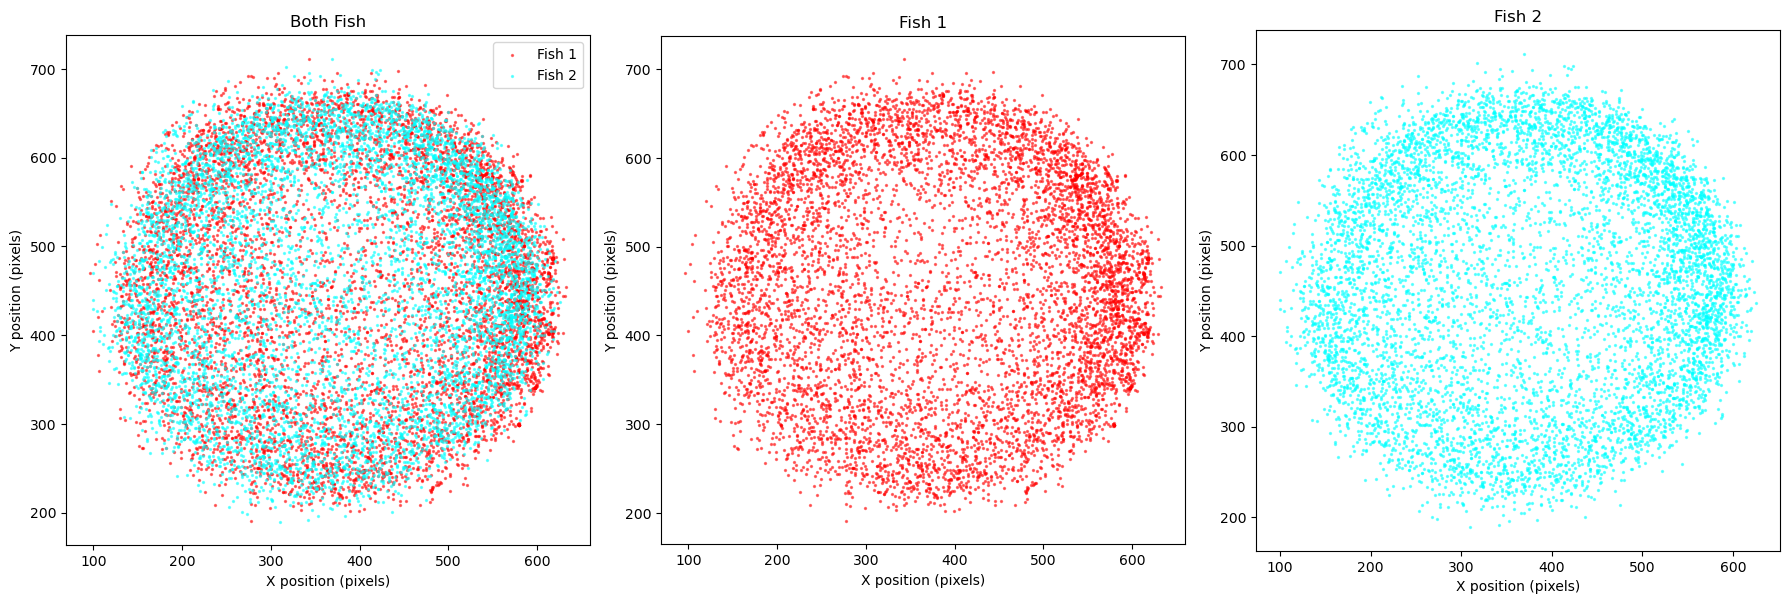

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Combined trajectories
axs[0].scatter(traj_x1_ds, traj_y1_ds, s=2, c='red', label='Fish 1', alpha=0.5)
axs[0].scatter(traj_x2_ds, traj_y2_ds, s=2, c='cyan', label='Fish 2', alpha=0.5)
axs[0].set_title("Both Fish")
axs[0].legend()

# Fish 1 only
axs[1].scatter(traj_x1_ds, traj_y1_ds, s=2, c='red', alpha=0.5)
axs[1].set_title("Fish 1")

# Fish 2 only
axs[2].scatter(traj_x2_ds, traj_y2_ds, s=2, c='cyan', alpha=0.5)
axs[2].set_title("Fish 2")

# Let matplotlib automatically zoom in on the data
for ax in axs:
    ax.set_aspect('equal')
    ax.set_xlabel("X position (pixels)")
    ax.set_ylabel("Y position (pixels)")
    ax.grid(False)

plt.tight_layout()
plt.show()




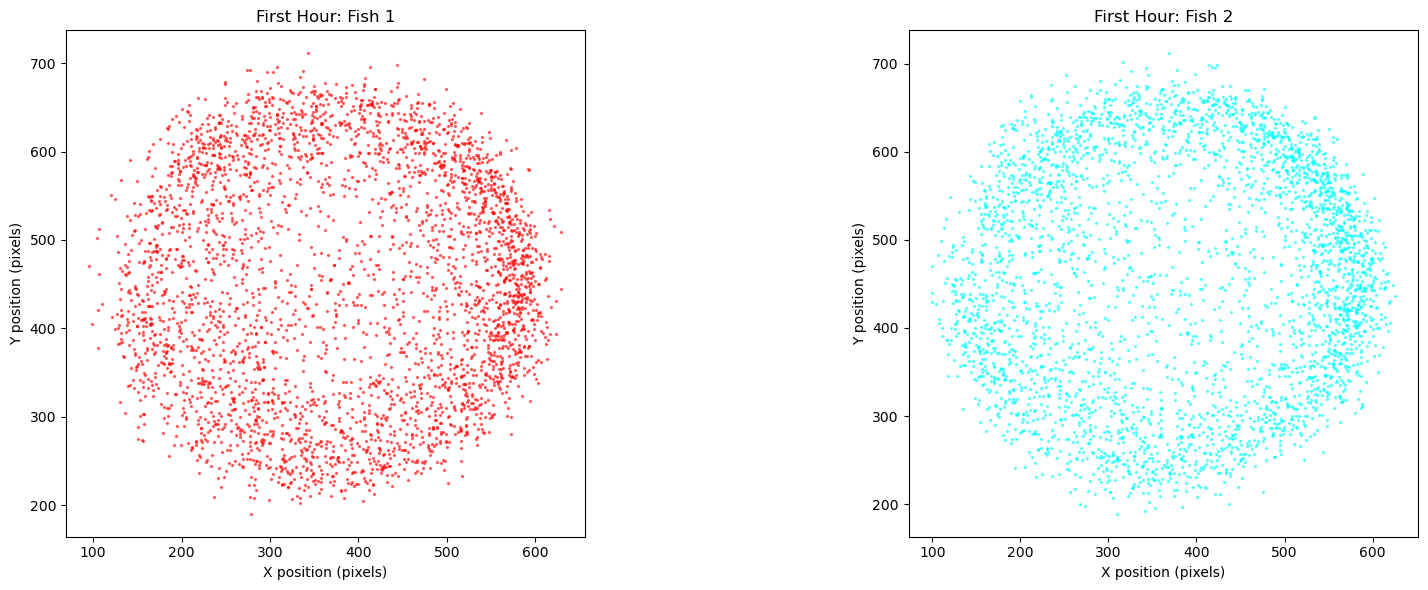

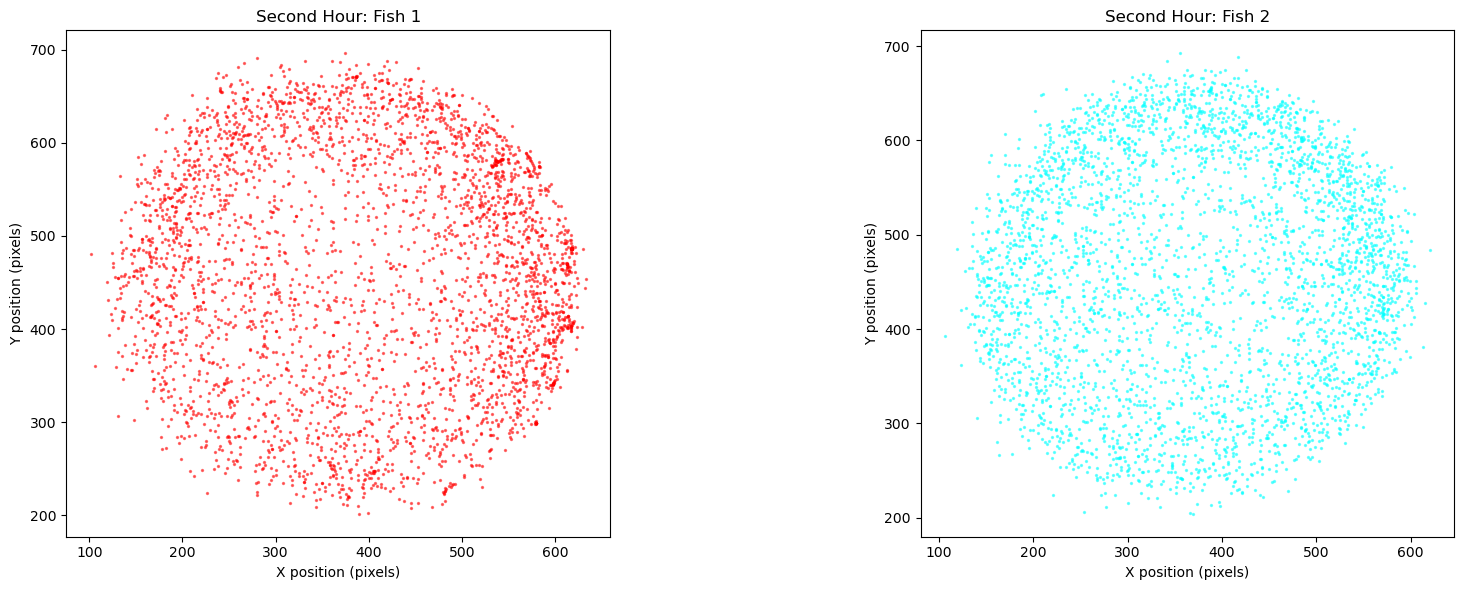

In [40]:
# define frame ranges
frames_per_hour = 60 * 60 * 60  # 216,000
first_hour_idx = slice(0, frames_per_hour)
second_hour_idx = slice(frames_per_hour, frames_per_hour*2)

# extract for fish 1
traj_x1 = data.iloc[:, 15].values
traj_y1 = data.iloc[:, 16].values

# extract for fish 2
traj_x2 = data.iloc[:, 17].values
traj_y2 = data.iloc[:, 18].values

# downsample to 1 second intervals
step = 60

# first hour downsampled
traj_x1_first = traj_x1[first_hour_idx][::step]
traj_y1_first = traj_y1[first_hour_idx][::step]
traj_x2_first = traj_x2[first_hour_idx][::step]
traj_y2_first = traj_y2[first_hour_idx][::step]

# second hour downsampled
traj_x1_second = traj_x1[second_hour_idx][::step]
traj_y1_second = traj_y1[second_hour_idx][::step]
traj_x2_second = traj_x2[second_hour_idx][::step]
traj_y2_second = traj_y2[second_hour_idx][::step]

# ---- Plot first hour ----
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

axs[0].scatter(traj_x1_first, traj_y1_first, s=2, c='red', alpha=0.5)
axs[0].set_title("First Hour: Fish 1")

axs[1].scatter(traj_x2_first, traj_y2_first, s=2, c='cyan', alpha=0.5)
axs[1].set_title("First Hour: Fish 2")

for ax in axs:
    ax.set_aspect('equal')
    ax.set_xlabel("X position (pixels)")
    ax.set_ylabel("Y position (pixels)")
    ax.grid(False)

plt.tight_layout()
plt.show()

# ---- Plot second hour ----
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

axs[0].scatter(traj_x1_second, traj_y1_second, s=2, c='red', alpha=0.5)
axs[0].set_title("Second Hour: Fish 1")

axs[1].scatter(traj_x2_second, traj_y2_second, s=2, c='cyan', alpha=0.5)
axs[1].set_title("Second Hour: Fish 2")

for ax in axs:
    ax.set_aspect('equal')
    ax.set_xlabel("X position (pixels)")
    ax.set_ylabel("Y position (pixels)")
    ax.grid(False)

plt.tight_layout()
plt.show()


Occupancy maps

In [ ]:
padding=20
# Compute occupancy histograms
bins = np.linspace(cx - a - padding, cx + a + padding, 50)

# Create new figure for Fish 1 and Fish 2 plots with histograms
fig, axs = plt.subplots(2, 2, figsize=(16, 14), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.4, 'wspace': 0.3})

# Top row: Trajectories
def draw_arena(ax):
    ellipse = Ellipse((cx, cy), width=major_axis, height=minor_axis,
                      angle=angle_deg, edgecolor='black', facecolor='none',
                      lw=2, linestyle='--', alpha=0.8)
    ax.add_patch(ellipse)

# Fish 1 trajectory
axs[0, 0].scatter(traj_x1_ds, traj_y1_ds, s=2, c='red', alpha=0.5)
draw_arena(axs[0, 0])
axs[0, 0].set_title("Fish 1")

# Fish 2 trajectory
axs[0, 1].scatter(traj_x2_ds, traj_y2_ds, s=2, c='cyan', alpha=0.5)
draw_arena(axs[0, 1])
axs[0, 1].set_title("Fish 2")

# Bottom row: Histograms
# Fish 1 histogram
axs[1, 0].hist(traj_x1_ds, bins=bins, color='red', alpha=0.7, label='Fish 1')
axs[1, 0].set_title("Fish 1")
axs[1, 0].set_xlabel("X position (pixels)")
axs[1, 0].set_ylabel("Frequency")
axs[1, 0].legend()

# Fish 2 histogram
axs[1, 1].hist(traj_x2_ds, bins=bins, color='cyan', alpha=0.7, label='Fish 2')
axs[1, 1].set_title("Fish 2")
axs[1, 1].set_xlabel("X position (pixels)")
axs[1, 1].set_ylabel("Frequency")
axs[1, 1].legend()

# Set axis limits for trajectories
for ax in axs[0, :]:
    ax.set_xlim(cx - a - padding, cx + a + padding)
    ax.set_ylim(cy + b + padding, cy - b - padding)  # Flip y-axis
    ax.set_aspect('equal')
    ax.set_xlabel("X position (pixels)")
    ax.set_ylabel("Y position (pixels)")
    ax.grid(False)

# Align histogram x-axis with trajectory x-axis
for ax in axs[1, :]:
    ax.set_xlim(cx - a - padding, cx + a + padding)

# Adjust layout
plt.tight_layout()
plt.show()

Parameter calculation

In [42]:
input_video_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_150mm_30dpf_pattern_vs_no_pattern_20250612/out_id0_60fps_20250612171329.avi"
output_video_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_150mm_30dpf_pattern_vs_no_pattern_20250612/cropped_output.mp4"
fps = 60

data = pd.read_csv(csv_path)
fish1 = data.iloc[:, [1, 2]].values
fish2 = data.iloc[:, [5, 6]].values

distance = np.linalg.norm(fish1 - fish2, axis=1)
speed1 = np.linalg.norm(np.diff(fish1, axis=0, prepend=fish1[0:1]), axis=1)
speed2 = np.linalg.norm(np.diff(fish2, axis=0, prepend=fish2[0:1]), axis=1)
acceleration1 = np.diff(speed1, prepend=speed1[0])
acceleration2 = np.diff(speed2, prepend=speed2[0])


# Replace NaNs with zeros or interpolate (if applicable)
distance = np.nan_to_num(distance)
speed1 = np.nan_to_num(speed1)
speed2 = np.nan_to_num(speed2)

#absolute heading
# fish1
delta_x1 = np.diff(fish1[:,0], prepend=fish1[0,0])
delta_y1 = np.diff(fish1[:,1], prepend=fish1[0,1])
heading1 = np.arctan2(delta_y1, delta_x1)  # in radians

# fish2
delta_x2 = np.diff(fish2[:,0], prepend=fish2[0,0])
delta_y2 = np.diff(fish2[:,1], prepend=fish2[0,1])
heading2 = np.arctan2(delta_y2, delta_x2)  # in radians

heading1_deg = np.degrees(heading1)
heading2_deg = np.degrees(heading2)

#relative heading
relative_heading = heading1 - heading2
relative_heading = (relative_heading + np.pi) % (2*np.pi) - np.pi  # wrap to -pi to pi


Plots over entire experiment

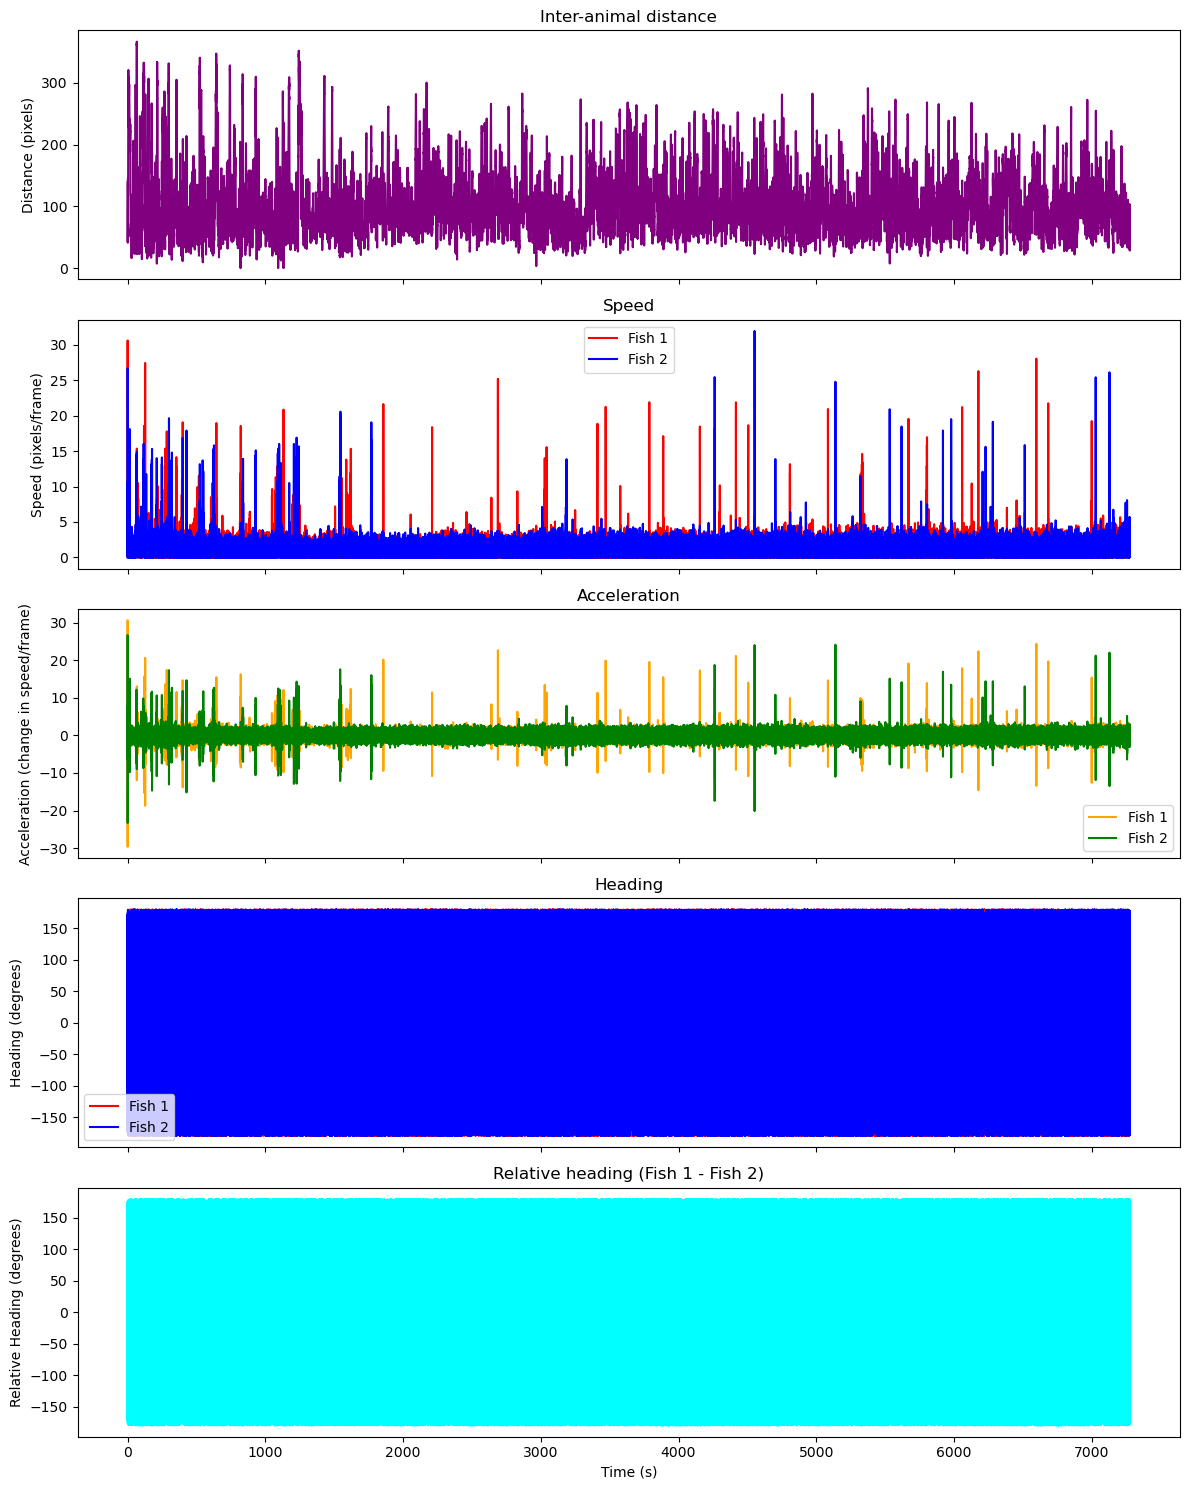

In [44]:
frames = np.arange(len(distance))
time_sec = frames / 60  # 60 fps

fig, axs = plt.subplots(5, 1, figsize=(12, 15), sharex=True)

# 1. Inter-animal distance
axs[0].plot(time_sec, distance, color='purple')
axs[0].set_ylabel("Distance (pixels)")
axs[0].set_title("Inter-animal distance")

# 2. Speeds
axs[1].plot(time_sec, speed1, label="Fish 1", color='red')
axs[1].plot(time_sec, speed2, label="Fish 2", color='blue')
axs[1].set_ylabel("Speed (pixels/frame)")
axs[1].set_title("Speed")
axs[1].legend()

# 3. Accelerations
axs[2].plot(time_sec, acceleration1, label="Fish 1", color='orange')
axs[2].plot(time_sec, acceleration2, label="Fish 2", color='green')
axs[2].set_ylabel("Acceleration (change in speed/frame)")
axs[2].set_title("Acceleration")
axs[2].legend()

# 4. Headings
axs[3].plot(time_sec, np.degrees(heading1), label="Fish 1", color='red')
axs[3].plot(time_sec, np.degrees(heading2), label="Fish 2", color='blue')
axs[3].set_ylabel("Heading (degrees)")
axs[3].set_title("Heading")
axs[3].legend()

# 5. Relative heading
relative_heading = heading1 - heading2
relative_heading = (relative_heading + np.pi) % (2*np.pi) - np.pi
axs[4].plot(time_sec, np.degrees(relative_heading), color='cyan')
axs[4].set_ylabel("Relative Heading (degrees)")
axs[4].set_xlabel("Time (s)")
axs[4].set_title("Relative heading (Fish 1 - Fish 2)")

plt.tight_layout()
plt.show()


Plots over time windows

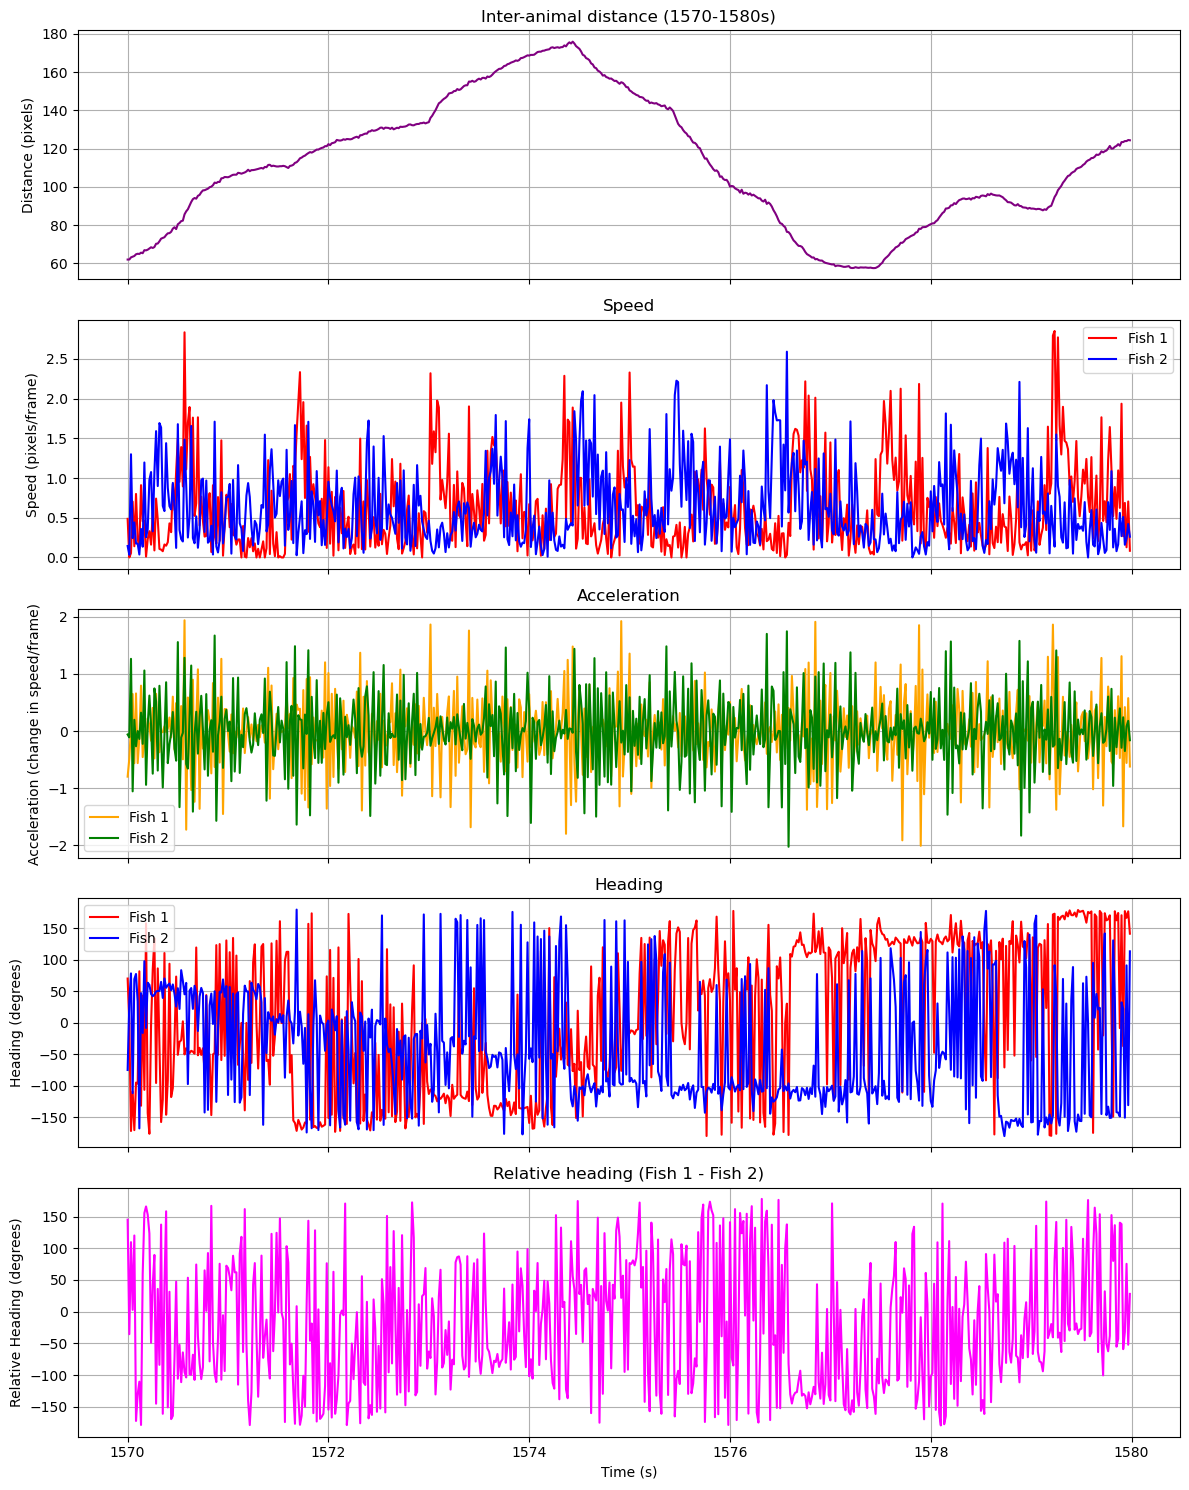

In [50]:
# define frame range
fps = 60
start_time_s = 1570
end_time_s = 1580

start_frame = start_time_s * fps
end_frame = end_time_s * fps

# slice data
distance_window = distance[start_frame:end_frame]
speed1_window = speed1[start_frame:end_frame]
speed2_window = speed2[start_frame:end_frame]
acceleration1_window = acceleration1[start_frame:end_frame]
acceleration2_window = acceleration2[start_frame:end_frame]
heading1_window = heading1[start_frame:end_frame]
heading2_window = heading2[start_frame:end_frame]

# absolute time in seconds
time_sec = np.arange(start_frame, end_frame) / fps

# plot
fig, axs = plt.subplots(5, 1, figsize=(12, 15), sharex=True)

# distance
axs[0].plot(time_sec, distance_window, color='purple')
axs[0].set_ylabel("Distance (pixels)")
axs[0].set_title(f"Inter-animal distance ({start_time_s}-{end_time_s}s)")
axs[0].grid(True)

# speed
axs[1].plot(time_sec, speed1_window, label="Fish 1", color='red')
axs[1].plot(time_sec, speed2_window, label="Fish 2", color='blue')
axs[1].set_ylabel("Speed (pixels/frame)")
axs[1].set_title("Speed")
axs[1].legend()
axs[1].grid(True)

# acceleration
axs[2].plot(time_sec, acceleration1_window, label="Fish 1", color='orange')
axs[2].plot(time_sec, acceleration2_window, label="Fish 2", color='green')
axs[2].set_ylabel("Acceleration (change in speed/frame)")
axs[2].set_title("Acceleration")
axs[2].legend()
axs[2].grid(True)

# headings
axs[3].plot(time_sec, np.degrees(heading1_window), label="Fish 1", color='red')
axs[3].plot(time_sec, np.degrees(heading2_window), label="Fish 2", color='blue')
axs[3].set_ylabel("Heading (degrees)")
axs[3].set_title("Heading")
axs[3].legend()
axs[3].grid(True)

# relative heading
rel_heading = heading1_window - heading2_window
rel_heading = (rel_heading + np.pi) % (2*np.pi) - np.pi
axs[4].plot(time_sec, np.degrees(rel_heading), color='magenta')
axs[4].set_ylabel("Relative Heading (degrees)")
axs[4].set_xlabel("Time (s)")
axs[4].set_title("Relative heading (Fish 1 - Fish 2)")
axs[4].grid(True)

plt.tight_layout()
plt.show()
